In [16]:
import pandas as pd
import numpy as np

# 1. Load the original dataset
df = pd.read_csv("AB_NYC_2019.csv")

# -----------------------------------
# 2. Text Normalization 
# -----------------------------------
# Standardizing text to lowercase to ensure consistency and improve grouping
df['name'] = df['name'].str.lower()
df['host_name'] = df['host_name'].str.lower()
df['neighbourhood'] = df['neighbourhood'].str.lower()

# -----------------------------------
# 3. Handling Missing Values and Duplicates
# -----------------------------------
# Removing duplicate rows
df.drop_duplicates(inplace=True)

# Dropping rows where essential information (listing or host name) is missing
df.dropna(subset=['name', 'host_name'], inplace=True)

# Filling missing values in 'reviews_per_month' with 0 as no reviews were recorded
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# -----------------------------------
# 4. Data Cleaning (Logical Filters)
# -----------------------------------
# Keeping realistic prices (between $1 and $1000)
df = df[(df['price'] > 0) & (df['price'] < 1000)]

# Removing listings with unrealistic 'minimum_nights' (more than a year)
df = df[df['minimum_nights'] < 365]

# -----------------------------------
# 5. Outlier Removal using IQR Method
# -----------------------------------
# Calculating the Interquartile Range (IQR) for the price column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering data to keep only values within the non-outlier range
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

# -----------------------------------
# 6. Final Formatting and Export
# -----------------------------------
# Dropping columns that are not useful for general data analysis
cols_to_drop = ['id', 'host_id', 'last_review']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Resetting the index to maintain a clean numerical order
df.reset_index(drop=True, inplace=True)

# Save the finalized cleaned dataset
df.to_csv("airbnb_cleaned.csv", index=False)

print("Final dataset is ready!")
print(f"Cleaned Data Shape: {df.shape}")
print(df.head())

Final dataset is ready!
Cleaned Data Shape: (45840, 13)
                                               name    host_name  \
0                clean & quiet apt home by the park         john   
1                             skylit midtown castle     jennifer   
2               the village of harlem....new york !    elisabeth   
3                   cozy entire floor of brownstone  lisaroxanne   
4  entire apt: spacious studio/loft by central park        laura   

  neighbourhood_group neighbourhood  latitude  longitude        room_type  \
0            Brooklyn    kensington  40.64749  -73.97237     Private room   
1           Manhattan       midtown  40.75362  -73.98377  Entire home/apt   
2           Manhattan        harlem  40.80902  -73.94190     Private room   
3            Brooklyn  clinton hill  40.68514  -73.95976  Entire home/apt   
4           Manhattan   east harlem  40.79851  -73.94399  Entire home/apt   

   price  minimum_nights  number_of_reviews  reviews_per_month  \
0    1

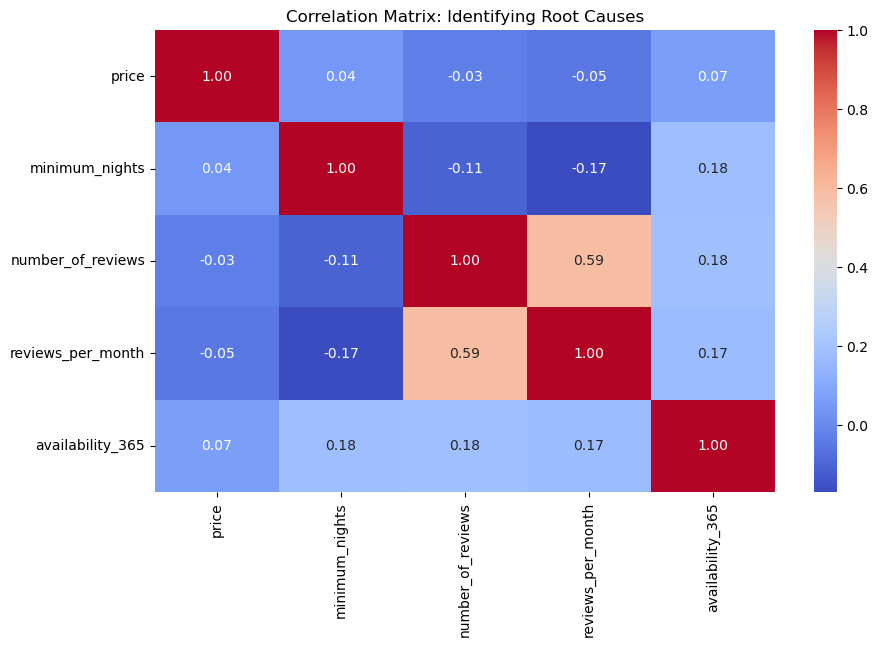

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("airbnb_cleaned.csv")

# ---------------------------------------------------------
# Heatmap (Root Causes)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Identifying Root Causes")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_9472\56987192.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='neighbourhood_group', y='price', data=df, palette='magma')
C:\Users\HP\AppData\Local\Temp\ipykernel_9472\56987192.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='neighbourhood_group', y='number_of_reviews', data=df, palette='viridis')


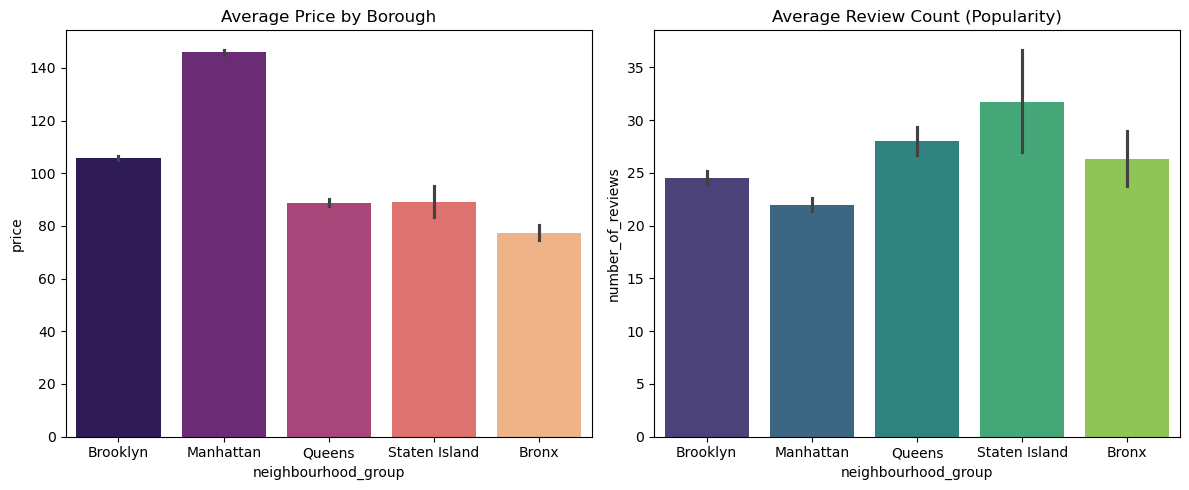

In [18]:
# (Boroughs)
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='neighbourhood_group', y='price', data=df, palette='magma')
plt.title("Average Price by Borough")

plt.subplot(1, 2, 2)
sns.barplot(x='neighbourhood_group', y='number_of_reviews', data=df, palette='viridis')
plt.title("Average Review Count (Popularity)")

plt.tight_layout()
plt.show()

In [19]:
# --- STEP 4: Strategy & Recommendations ---

# 1. Calculate Market Averages (Benchmarks)
avg_price = df['price'].mean()
avg_reviews = df['reviews_per_month'].mean()

# 2. Define the Recommendation Logic
def get_recommendation(row):
    # Case A: High Price + Low Reviews (Needs immediate change)
    if row['price'] > avg_price and row['reviews_per_month'] < avg_reviews:
        return "Lower price to increase bookings"
    
    # Case B: High Minimum Nights (Affects visibility)
    elif row['minimum_nights'] > 3:
        return "Reduce minimum nights for more traffic"
    
    # Case C: Good Performance
    elif row['reviews_per_month'] >= avg_reviews:
        return "Keep current strategy"
    
    # Case D: Default
    else:
        return "Improve listing description"

# 3. Apply the logic and create a new column
df['final_recommendation'] = df.apply(get_recommendation, axis=1)

# 4. Print a summary of the results
print("Summary of Recommendations for NYC Hosts:")
print(df['final_recommendation'].value_counts())

# 5. Export the results to a new file
df.to_csv("airbnb_recommendations_report.csv", index=False)
print("\nSuccess: Final report 'airbnb_recommendations_report.csv' is ready!")

Summary of Recommendations for NYC Hosts:
final_recommendation
Lower price to increase bookings          13698
Keep current strategy                     12369
Improve listing description               10604
Reduce minimum nights for more traffic     9169
Name: count, dtype: int64

Success: Final report 'airbnb_recommendations_report.csv' is ready!
